# Baseline Model Training

## baseline_train — Process Flow Outline

- **0. Goal / Outputs**
  - Reproducible baseline (fixed split/CV, metrics, seeds)
  - Comparable CV results
  - Final test report + next-stage improvement list

- **1. Data Preprocessing (sklearn)**
  - Define: target, feature columns, numeric vs categorical
  - Build `ColumnTransformer` + `Pipeline`
  - Fit transforms on **train only** (avoid leakage)
  - Output: processed features + saved preprocessing pipeline

- **2. Cross Validation (PyTorch Logistic Baseline)**
  - CV: `StratifiedKFold` (classification)
  - Model: Logistic Regression equivalent (linear layer + sigmoid/softmax)
  - Output: locked evaluation protocol (metric, threshold, CV config)

- **3. Train Baseline Model**
  - Use the same model as Step 2
  - Train on full train set with selected hyperparameters
  - Output: baseline performance (CV mean±std if applicable) + learning curves

- **4. Hyperparameter Optimization**
  - Keep the same CV framework
  - Search method: random / bayes / Optuna
  - Search space (examples): lr, wd, batch size, epochs, class weights
  - Output: best config + validation score summary

- **5. Final Evaluation (Test) + Next Steps**
  - Run test evaluation once (no tuning on test)
  - Report: primary metric + confusion matrix (and calibration if needed)
  - Error analysis: weak classes/slices, imbalance, redundancy
  - Next-stage plan: stronger models, feature engineering, thresholding, data work


## Package Import & Path Setting

In [5]:
from pathlib import Path
import pandas as pd
from pandas import DataFrame as df
import numpy as np
import matplotlib.pyplot as plt

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# preprocessing & structure
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# pytorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# other imports
from tqdm.auto import tqdm
from sklearn.dummy import DummyClassifier

In [6]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
else:
    print("Using CPU version")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8


In [ ]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_data_path = DATA_DIR / 'train.csv'
test_data_path = DATA_DIR / 'test.csv'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Data Loading

In [ ]:
train_raw_df = pd.read_csv(train_data_path)
test_raw_df = pd.read_csv(test_data_path)

X = train_raw_df.drop('Survived', axis=1)
y = train_raw_df['Survived'] 

## Data Preprocessing

* Columns to drop: `Name`, `Cabin`, `Ticket`
* Numeral columns: `Age`, `Fare`, `SibSp`, `Parch`
* Numeral columns to be scaled: `Age`, `Fare`
* Categorical columns: `Sex`, `Pclass`, `Embarked`

In [9]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols = ['Sex', 'Pclass', 'Embarked']

def create_new_preprocess():
    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
        ],
        remainder='drop'
    )
    return preprocess

* A data preprocessing pipeline is constructed using `ColumnTransformer`.
* The weak impact features `Embarked` and `Parch` are included, and they will be the subjects to feature ablation.

## Evaluation Method
* Baseline Model: Logistic Regression
* Split Stragety: Stratified KFold (5 Folds)
* Metrics: Accuracy, ROC-AUC

### Baseline Model

In [10]:
# baseline model
class LogisticClass(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(1)

 
# training class
class Trainer():
    def __init__(self, model, optimizer, loss_fn, metrics, device=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.hist = {"loss": [], "val_loss": []}
        for name in self.metrics.keys():
            self.hist[name] = []        

    def train(self, train_data, val_data, batch_size, epochs):
        X_tr_np, y_tr_np = train_data
        X_val_np, y_val_np = val_data
        
        X_tr = torch.tensor(X_tr_np, dtype=torch.float32)
        y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
        X_val = torch.tensor(X_val_np, dtype=torch.float32)
        y_val = torch.tensor(y_val_np, dtype=torch.float32)

        if y_tr.ndim == 1:
            y_tr = y_tr.view(-1, 1)
        if y_val.ndim == 1:
            y_val = y_val.view(-1, 1)

        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)             

        # for epoch in range(epochs):
        for epoch in tqdm(range(epochs), desc="Training", leave=False):
            self.model.train()
            total_loss = 0
            total_n = 0
            for x, y in train_loader:
                x = x.to(self.device)
                y = y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(x).squeeze()
                loss = self.loss_fn(logits, y.squeeze())
                actual_bs = x.size(0)
                total_loss += loss.item() * actual_bs
                total_n += actual_bs
                loss.backward()
                self.optimizer.step()
            self.hist['loss'].append(total_loss / max(total_n, 1))            
            # validation
            self.model.eval()
            val_total_loss = 0
            val_total_n = 0            
            probs_list = []
            with torch.no_grad():
                for x, y in val_loader:
                    x = x.to(self.device)
                    y = y.to(self.device)
                    logits = self.model(x).squeeze()
                    loss = self.loss_fn(logits, y.squeeze())
                    actual_bs = x.size(0)
                    val_total_loss += loss.item() * actual_bs
                    val_total_n += actual_bs
                    p = torch.sigmoid(logits).detach().cpu().numpy()
                    probs_list.append(p)
            
            self.hist["val_loss"].append(val_total_loss / max(val_total_n, 1))
            probs = np.concatenate(probs_list, axis=0)
            probs_1d = probs.reshape(-1)

            for name, spec in self.metrics.items():
                if spec["input_type"] == "prob":
                    self.hist[name].append(spec["func"](y_val, probs_1d))
                elif spec["input_type"] == "label":
                    pred = (probs_1d >= 0.5).astype(int)
                    self.hist[name].append(spec["func"](y_val, pred))
                else:
                    raise ValueError(f"Unknown input_type for metric '{name}': {spec['input_type']}")
        return self.hist
    

### Train Data Splitting Test


CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 1 auc score (baseline / dummy): 0.8324 / 0.5000, acc score: 0.7095 / 0.6145


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 2 auc score (baseline / dummy): 0.8463 / 0.5000, acc score: 0.7753 / 0.6180


...

Fold 3 auc score (baseline / dummy): 0.8630 / 0.5000, acc score: 0.8034 / 0.6180


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 4 auc score (baseline / dummy): 0.8291 / 0.5000, acc score: 0.7809 / 0.6180


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Fold 5 auc score (baseline / dummy): 0.8141 / 0.5000, acc score: 0.7753 / 0.6124
Baseline Model AUC/ACC Mean: 0.8370 ± 0.0166 / 0.7689 ± 0.0314
Dummy Model AUC/ACC Mean: 0.5000 ± 0.0000 / 0.6162 ± 0.0023
Baseline Model AUC/ACC Lift: 0.3370 / 0.1527


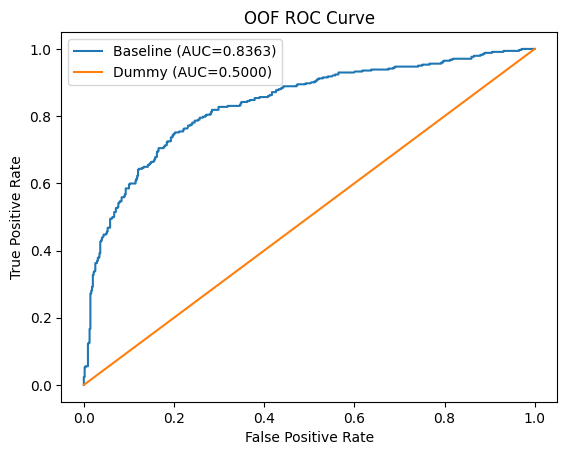

In [11]:
## skf
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)
batch_size = 64
epochs = 5
lr = 1e-2
weight_decay=0.0
loss_fn = nn.BCEWithLogitsLoss()

metrics = {'acc':{'input_type':'label', 'func':accuracy_score},
           'auc':{'input_type':'prob', 'func':roc_auc_score}
           }

acc_scores = []
auc_scores = []
dummy_acc_scores = []
dummy_auc_scores = []
oof_probs = []
oof_y_val = []
oof_dummy_probs = []

pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")

for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
    X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    preprocess = create_new_preprocess()
    X_tr_np = preprocess.fit_transform(X_tr_raw)
    X_val_np = preprocess.transform(X_val_raw)
    train_data = X_tr_np, y_tr.to_numpy()
    val_data = X_val_np, y_val.to_numpy()
    model = LogisticClass(12).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    trainer = Trainer(model, optimizer, loss_fn, metrics, device=DEVICE)
    hist = trainer.train(train_data, val_data, batch_size, epochs)
    with torch.no_grad():
        X_val = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)
        logits = trainer.model(X_val)
        p = torch.sigmoid(logits).cpu().numpy()
    oof_probs.append(p)
    oof_y_val.append(y_val)
    pred = (p >= 0.5).astype(int).squeeze()
    auc_score = roc_auc_score(y_val, p)
    acc_score = accuracy_score(y_val, pred)
    acc_scores.append(acc_score)
    auc_scores.append(auc_score)
    # dummy model
    dummy_model = DummyClassifier(strategy='most_frequent', random_state=37)
    dummy_model.fit(X_tr_np, y_tr.to_numpy())
    dummy_pred = np.asarray(dummy_model.predict(X_val_np), dtype=int).ravel()
    dummy_prob = np.asarray(dummy_model.predict_proba(X_val_np)[:, 1], dtype=float).ravel()
    oof_dummy_probs.append(dummy_prob)
    dummy_acc_score = accuracy_score(y_val, dummy_pred)
    dummy_acc_scores.append(dummy_acc_score)
    dummy_auc_score = roc_auc_score(y_val, dummy_prob)
    dummy_auc_scores.append(dummy_auc_score)
    tqdm.write(f"Fold {fold} auc score (baseline / dummy): {auc_score:.4f} / {dummy_auc_score:.4f}, acc score: {acc_score:.4f} / {dummy_acc_score:.4f}")

print(f"Baseline Model AUC/ACC Mean: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f} / {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Dummy Model AUC/ACC Mean: {np.mean(dummy_auc_scores):.4f} ± {np.std(dummy_auc_scores):.4f} / {np.mean(dummy_acc_scores):.4f} ± {np.std(dummy_acc_scores):.4f}")
print(f'Baseline Model AUC/ACC Lift: {(np.mean(auc_scores) - np.mean(dummy_auc_scores)):.4f} / {(np.mean(acc_scores) - np.mean(dummy_acc_scores)):.4f}')

plt.figure()
oof_probs = np.concatenate(oof_probs)
oof_y_val = np.concatenate(oof_y_val)
auc = roc_auc_score(oof_y_val, oof_probs)
fpr, tpr, thr = roc_curve(oof_y_val, oof_probs)
plt.plot(fpr, tpr, label=f'Baseline (AUC={auc:.4f})')
oof_dummy_probs = np.concatenate(oof_dummy_probs)
dummy_auc = roc_auc_score(oof_y_val, oof_dummy_probs)
fpr, tpr, thr = roc_curve(oof_y_val, oof_dummy_probs)
plt.plot(fpr, tpr, label=f'Dummy (AUC={dummy_auc:.4f})')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"OOF ROC Curve")
plt.legend()
plt.show()



* The result shows that current baseline mode performs well under 5 fold splitting.


## Baseline Model Optimization
* Metrics: Accuracy, AUC
* Search Method: Random
* Hyperparameters: `lr`, `weight_decay`, `epochs`, `batch_size`


In [12]:


def cv_eval_fn(params):
    lr = params['lr']
    weight_decay = params['weight_decay']
    batch_size = params['batch_size']
    epochs = params['epochs']
    loss_fn = nn.BCEWithLogitsLoss()

    metrics = {'acc':{'input_type':'label', 'func':accuracy_score},
            'auc':{'input_type':'prob', 'func':roc_auc_score}
            }
    acc_scores = []
    auc_scores = []

    pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")

    for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        preprocess = create_new_preprocess()
        X_tr_np = preprocess.fit_transform(X_tr_raw)
        X_val_np = preprocess.transform(X_val_raw)
        train_data = X_tr_np, y_tr.to_numpy()
        val_data = X_val_np, y_val.to_numpy()
        model = LogisticClass(12).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        trainer = Trainer(model, optimizer, loss_fn, metrics, device=DEVICE)
        hist = trainer.train(train_data, val_data, batch_size, epochs)
        with torch.no_grad():
            X_val = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)
            logits = trainer.model(X_val)
            p = torch.sigmoid(logits).cpu().numpy()
   
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)    

    mean_score = np.mean(auc_scores)
    std_score = np.std(auc_scores) 
    # pbar.postfix(f'Score: {mean_score:.4f}±{std_score:.4f}')
    return mean_score, std_score, model


def log_uniform(rng: np.random.Generator, low: float, high: float) -> float:
    """Sample from log-uniform(low, high)."""
    return float(10 ** rng.uniform(np.log10(low), np.log10(high)))

def sample_params(rng: np.random.Generator) -> dict:
    """Randomly sample a hyperparameter configuration."""
    return {
        "lr": log_uniform(rng, 1e-4, 3e-1),
        "weight_decay": log_uniform(rng, 1e-8, 1e-2),
        "batch_size": int(rng.choice([32, 64, 128])),
        "epochs": 20,  # keep fixed first; tune later if needed
    }

def random_search(rng: np.random.Generator, n_trials: int, cv_eval_fn):
    """
    cv_eval_fn(params) -> (mean_score, std_score)
    """
    best = None
    best_model = None
    history = []
    pbar = tqdm(range(n_trials), desc="HPO trials")
    for t in pbar:
        params = sample_params(rng)
        mean_score, std_score, model = cv_eval_fn(params)

        record = {"trial": t, **params, "mean": mean_score, "std": std_score}
        history.append(record)

        # simple selection rule: prefer high mean, break ties by low std
        if (best is None) or (mean_score > best["mean"]) or (
            mean_score == best["mean"] and std_score < best["std"]
        ):
            best = record
            best_model = model
        pbar.set_postfix(best_mean=f"{best['mean']:.4f}", lr=f"{best['lr']:.2e}", wd=f"{best['weight_decay']:.2e}")

    
    return best, history, best_model


In [13]:
rng = np.random.default_rng(37)
best, history, best_model = random_search(rng, 20, cv_eval_fn)


HPO trials:   0%|          | 0/20 [00:00<?, ?it/s]

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

...

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

In [14]:
for k, v in best.items():
    if v > 1e-3:
        print(f'{k}: {v:d}') if type(v) == int else print(f'{k}, {v:.4f}')
    else:
        print(f'{k}: {v:.4e}')
                

trial: 0.0000e+00
lr, 0.0281
weight_decay: 9.3328e-05
batch_size: 32
epochs: 20
mean, 0.8506
std, 0.0148


### Optimized Model Performance

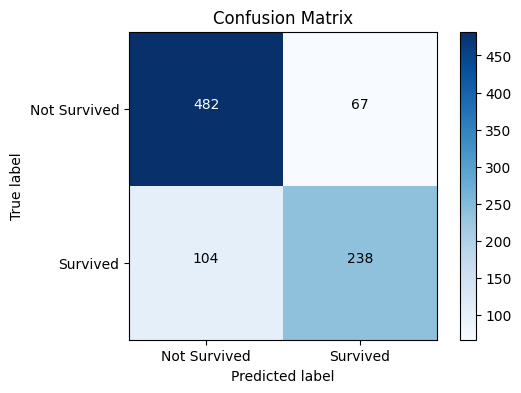

              precision    recall  f1-score   support

not survived       0.82      0.88      0.85       549
    survived       0.78      0.70      0.74       342

    accuracy                           0.81       891
   macro avg       0.80      0.79      0.79       891
weighted avg       0.81      0.81      0.81       891



In [19]:
X_np = preprocess.transform(X)
X_tr = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
best_model.eval()
with torch.no_grad():
    logits = best_model(X_tr)
    prob = torch.sigmoid(logits).cpu().detach().numpy()
    y_pred = (prob >= 0.5).astype(int).squeeze()

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Survived', 'Survived'])
plt.yticks(tick_marks, ['Not Survived', 'Survived'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.show()

print(classification_report(y, y_pred, target_names=['not survived', 'survived']))


The evaluation result shows that the model does better in casualty prediction. High recall rate in `survived` may be acceptable from a preventive perspective.

## Baseline Model on Test Data

In [20]:
# Assuming 'preprocess' is the ColumnTransformer fitted on train data
# and 'best_model' is the trained PyTorch model from HPO

# Preprocess the test data (use transform, not fit_transform to avoid leakage)
X_test_np = preprocess.transform(test_raw_df)

# Convert to tensor and predict
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32).to(DEVICE)
best_model.eval()
with torch.no_grad():
    logits = best_model(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()
    y_test_pred = (probs >= 0.5).astype(int).squeeze()

# Create submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': test_raw_df['PassengerId'],
    'Survived': y_test_pred
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created.")



Submission file 'submission.csv' created.


The submission only scores ~0.77 on Kaggle leaderboard. I wonder if it could be improved in the next phase.